# <u>Supervised Deep Learning</u>

### Prerequisites:
* <a href="../Artificial Neural Networks/Neural Networks.ipynb">Check out the notebook on Neural Networks</a>

## Topics

* [1. Introduction](#perceptron)



In [47]:
import numpy as np  # for random numbers and numpy arrays
import pandas as pd # for dataframes
import matplotlib.pyplot as plt # for 2D Plots


# Neural network classes
#import sklearn
#from sklearn.neural_network import MLPClassifier
#from sklearn.neural_network import MLPRegressor
#print(sklearn.__version__)

# PyTorch
#import torch # main PyTorch library for i.e. multi-dimensional arrays
#import torch.nn.functional as F # PyTorch's functional API
#import torch.nn as nn # imports PyTorch's neural network module which contains layers and model-building components 
                      # i.e. nn.Linear(10,5) meaning 10 input neurons and 5 output neurons and 
                      # i.e. model = nn.Sequential(
                      #                  nn.Linear(10, 5),  # input -> hidden
                      #                  nn.ReLU(),         # or nn.Sigmoid()
                      #                  nn.Linear(5, 1)    # hidden -> output
                      #      )
#import torch.optim as optim # Imports optimization algorithms used during training and ppdates model weights to minimize loss
                            # i.e. optim.SGD(model.parameters(), lr=0.01) or optim.Adam(model.parameters(), lr=0.001)
#print(torch.__version__)

# TensorFlow / Keras (Deep learning framework)
#import tensorflow as tf # Imports the main TensorFlow library and provides tensors, automatic differentiation, distributed computing 
                        # and deep learning tools (i.e. x = tf.constant([1, 2, 3]))
#from tensorflow import keras # Imports Keras, TensorFlow's high-level deep learning API. It makes building neural networks easier (i.e. model = keras.Sequential())
#from tensorflow.keras import layers # Imports common neural network layers used when constructing models (i.e. layers.Dense(64, activation='relu'))
#print(tf.__version__)

#from sklearn.datasets import load_iris # Iris dataset
from sklearn.preprocessing import StandardScaler # Standardize features
from sklearn.model_selection import train_test_split # split dataset in train and testset
from sklearn.metrics import accuracy_score # accuracy score

#from sklearn.datasets import make_s_curve # create synthetic toy data
from sklearn.datasets import make_moons # create synthetic toy data
from sklearn.datasets import make_circles # create synthetic toy data
from sklearn.datasets import make_classification # create synthetic toy data

print("Setup complete")

Setup complete


<a class="anchor" id="intro"></a>

# 1. Introduction

**Deep learning is based on neural networks with multiple hidden layers.**

**The main challenge in deep learning is usually not making a model complex enough, but preventing it from memorizing the training data (overfitting) while still optimizing efficiently.**

Deep learning aims to learn a function $$f(x,\theta)$$ where 
- $x =$  input
- $\theta = $ all weights and biases
- $f =$ neural network
Training consists of minimizing a loss function $$L(\theta)$$ using gradient descent.

A deep network often has millions or billions of parameters, making it extremely expressive. This expressive power creates two major problems:

1. Overfitting: the model memorizes the training data.
2. Optimization difficulties: training becomes unstable or slow.


<a class="anchor" id="reg"></a>

# 2. Regularization

Regularization means adding constraints that encourage simpler models and  minimize the chances of overfitting to the training data so instead of only minimizing the prediction error, we also penalize large weights. The general objective becomes

$$
\min_\theta \mathcal{R}_\text{reg}(\theta)=\min_\theta  (\mathcal{R}_\text{emp}(\theta) + \lambda J(\theta))
$$ where

- $\mathcal{R}_\text{emp}(\theta)$ is the original loss
- $(\theta)$ is the regularization term
- $\lambda \in [0,\infty)$ is the hyperparameter controlling the regularization strength
- Note: In general we do not penalize the bias

<a class="anchor" id="L2"></a>

### 2.1 L2-Regularization

$$
\min_\theta \mathcal{R}_\text{reg}(\theta)=\min_\theta  (\mathcal{R}_\text{emp}(\theta) + \lambda \frac{1}{2}\lVert \theta \rVert_2^2)
$$ where

- $J(\theta)=\frac{1}{2}\lVert \theta \rVert_2^2$ using the L2-Norm $\lVert \theta \rVert_2$

**Why shrink weights?**
- Large weights make the network highly sensitive
    - Small input changes can lead to large output changes
- Keeping weights small generally produces smoother functions that generalize better

**Gradient**

Without regularization $$\theta^{[t+1]}=\theta^{[t]} - \alpha \nabla_\theta \mathcal{R}_\text{emp}(\theta^{[t]})$$

With L2 regularization $$\theta^{[t+1]}=\theta^{[t]} - \alpha \underbrace{(\nabla_\theta \mathcal{R}_\text{emp}(\theta^{[t]}) + \lambda \theta^{[t]})}_{= \nabla_\theta \mathcal{R}_\text{reg}(\theta^{[t]})}$$

The additional term continuously pushes weights toward zero

**Effect**

Instead of eliminating weights entirely, L2 regularization:
- discourages large weights
- spreads information across many parameters
- improves generalization


<a class="anchor" id="WD"></a>

### 2.2 Weight Decay

Weight decay is closely related to L2 regularization.

Instead of adding a penalty to the loss, we directly shrink the weights every update:
$$
\theta^{[t+1]}=(1-\alpha \lambda)\theta^{[t]} - \alpha \nabla_\theta \mathcal{R}_\text{emp}(\theta^{[t]})
$$


So each iteration consists of:
1. multiply weights by slightly less than 1
2. perform gradient update

### 2.3 L2-Regularization=Weight Decay

For plain (Stochastic) Gradient Descent, L2 regularization and weight decay are mathematically equivalent.
$$
\begin{align*}
\theta^{[t+1]}&=\theta^{[t]} - \alpha (\nabla_\theta \mathcal{R}_\text{emp}(\theta^{[t]}) + \lambda \theta^{[t]}) \\
&=\theta^{[t]}-\alpha \nabla_\theta \mathcal{R}_\text{emp}(\theta^{[t]}) - \alpha \lambda \theta^{[t]} \\
&=\theta^{[t]}- \alpha \lambda \theta^{[t]}-\alpha \nabla_\theta \mathcal{R}_\text{emp}(\theta^{[t]}) \\
&=(1-\alpha \lambda)\theta^{[t]} - \alpha \nabla_\theta \mathcal{R}_\text{emp}(\theta^{[t]})
\end{align*}
$$

For adaptive optimizers like Adam, they are not equivalent, which is why optimizers such as AdamW explicitly implement weight decay.

<a class="anchor" id="ex1"></a>

### 2.4  Example 1: Effect of regularization strength $\lambda$ on weights 

$$
y = \tau(W^{(2)}\sigma(W^{(1)}x + b^{(1)}) + b^{(2)})
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/92_.jpeg" width="550"/>
</div>


- $W^{(1)} \in \mathbb{R}^{10 \times 2}$
- $b^{(1)} \in \mathbb{R}^{10}$
- $X \in \mathbb{R}^{N \times 2}$
- $W^{(2)} \in \mathbb{R}^{1 \times 10}$
- $b^{(2)} \in \mathbb{R}^{1}$
- $\sigma(x)=\text{ReLU}(x)=\max(0,x)$
- $\tau(x)=\text{sigmoid}(x)=\frac{1}{1+\exp(-x)}$
- $\lambda \in \{0,0.001,0.005,0.01\}$ Regularization strength

##### Forward propagation
- $Z^{(0)}=X=\begin{bmatrix}x_1^\top  \\ x_2^\top \\ \vdots \\ x_N^\top \end{bmatrix}$
- $A^{(1)}=\underbrace{Z^{(0)}(W^{(1)})^\top}_{(N \times 2)(2 \times 10)=(N \times 10)} + \underbrace{1_N(b^{(1)})^\top}_{N \times 10} \in \mathbb{R}^{N \times 10}$
- $Z^{(1)}=\sigma(A^{(1)})=\text{ReLU}(A^{(1)}) \in \mathbb{R}^{N \times 10}$
- $A^{(2)}=\underbrace{Z^{(1)}(W^{(2)})^\top}_{(N \times 10)(10 \times 1)=(N \times 1)} + \underbrace{1_Nb^{(2)}}_{N \times 1} \in \mathbb{R}^{N \times 1}$
- $Z^{(2)}=\tau(A^{(2)})=\text{sigmoid}(A^{(2)}) \in \mathbb{R}^{N \times 1}$
- $Y=Z^{(2)}$
- Binary Cross-Entropy loss $\mathcal{R}_\text{emp}(\ldots)=L(Y,T)=-\frac{1}{N} \sum_{i=1}^N \left[T_i \log(Y_i) + (1-T_i)\log(1-Y_i)\right]$ with $T \in \mathbb{R}^{N \times 1}$


##### Backward propagation with L2 Regularization

Our Regularized Loss is 
$$
\mathcal{R}_\text{reg}(\ldots) = \mathcal{R}_\text{emp}(\ldots) + \frac{\lambda }{2}(\lVert W^{(1)}\rVert_F^2 + \lVert W^{(2)}\rVert_F^2)
$$
and typically we do not regularize biases.

$$
\begin{align*}
\frac{\partial \mathcal{R}_\text{reg}}{\partial b^{(2)}}&=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\frac{\partial A^{(2)}}{\partial b^{(2)}} \\

\frac{\partial \mathcal{R}_\text{reg}}{\partial W^{(2)}}&=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\frac{\partial A^{(2)}}{\partial W^{(2)}} \frac{\partial }{\partial W^{(2)}} \frac{\lambda }{2}(\lVert W^{(1)}\rVert_F^2 + \lVert W^{(2)}\rVert_F^2) \\


\frac{\partial \mathcal{R}_\text{reg}}{\partial b^{(1)}}&=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\frac{\partial A^{(2)}}{\partial Z^{(1)}}\frac{\partial Z^{(1)}}{\partial A^{(1)}}\frac{\partial A^{(1)}}{\partial b^{(1)}} \\


\frac{\partial \mathcal{R}_\text{reg}}{\partial W^{(1)}}&=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\frac{\partial A^{(2)}}{\partial Z^{(1)}}\frac{\partial Z^{(1)}}{\partial A^{(1)}}\frac{\partial A^{(1)}}{\partial W^{(1)}} \frac{\partial }{\partial W^{(1)}} \frac{\lambda }{2}(\lVert W^{(1)}\rVert_F^2 + \lVert W^{(2)}\rVert_F^2) \\
\end{align*}
$$
---
$$
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}} = 1
$$


$$
\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}=\frac{1}{N}\left(-\frac{T}{Y} + \frac{1-T}{1-Y}\right)
$$

$$
\begin{align*}
\frac{\partial Y}{\partial A^{(2)}}
&=\frac{\partial}{\partial A^{(2)}} \tau(A^{(2)})\\
&=\frac{\partial}{\partial A^{(2)}} \frac{1}{1+\exp(-A^{(2)})} \\
&=\frac{\partial}{\partial A^{(2)}} (1+\exp(-A^{(2)}))^{-1} \\
&= -(1+\exp(-A^{(2)}))^{-2}\frac{\partial}{\partial A^{(2)}}(1+\exp(-A^{(2)}))  \\
&= -(1+\exp(-A^{(2)}))^{-2}(-\exp(-A^{(2)}))  \\
&= \frac{\exp(-A^{(2)})}{(1+\exp(-A^{(2)}))^2} \hspace{1 mm} \mid \hspace{1 mm} Y=\frac{1}{1+\exp(-A^{(2)})}, 1-Y=\frac{\exp(-A^{(2)})}{1+\exp(-A^{(2)})} \\
&= Y \odot (1-Y)
\end{align*}
$$

---

$$
\begin{align*}
\frac{\partial \mathcal{R}_\text{reg}}{\partial b^{(2)}}&= \underbrace{\left(\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\right)}_{:=\delta^{(2)}=\frac{1}{N}(Y-T)}\frac{\partial A^{(2)}}{\partial b^{(2)}}\\ &= 1 \cdot 1 \cdot \frac{1}{N} \left(-\frac{T}{Y}+\frac{1-T}{1-Y}\right) \cdot Y \odot (1-Y) \cdot 1 = \frac{1}{N}1_N^\top (Y - T) \\

\frac{\partial \mathcal{R}_\text{reg}}{\partial W^{(2)}}&=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\frac{\partial A^{(2)}}{\partial W^{(2)}} \frac{\partial }{\partial W^{(2)}} \frac{\lambda }{2}(\lVert W^{(1)}\rVert_F^2 + \lVert W^{(2)}\rVert_F^2) \\ &=(\delta^{(2)})^\top Z^{(1)} + \lambda W^{(2)} \\


\frac{\partial \mathcal{R}_\text{reg}}{\partial b^{(1)}}
&=\underbrace{\left(\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\frac{\partial A^{(2)}}{\partial Z^{(1)}}\frac{\partial Z^{(1)}}{\partial A^{(1)}}\right)}_{:=\delta^{(1)}}\frac{\partial A^{(1)}}{\partial b^{(1)}} \\ 
&=\underbrace{\left(\delta^{(2)}W^{(2)} \odot \frac{\partial}{\partial A^{(1)}}\text{ReLU}(A^{(1)})\right)}_{\delta^{(1)} \text{ of shape } N \times 10} \odot 1_N \\ 
&=1_N^\top \delta^{(1)} \quad \mid \quad

\left[\frac{\partial}{\partial A^{(1)}}\text{ReLU}(A^{(1)})\right]_{ij}=\begin{cases} 1 &, A_{ij}^{(1)} > 0 \\ 0 &, A_{ij}^{(1)} \leq 0  \end{cases}
\\

\frac{\partial \mathcal{R}_\text{reg}}{\partial W^{(1)}}&=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\frac{\partial A^{(2)}}{\partial Z^{(1)}}\frac{\partial Z^{(1)}}{\partial A^{(1)}}\frac{\partial A^{(1)}}{\partial W^{(1)}} \frac{\partial }{\partial W^{(1)}} \frac{\lambda }{2}(\lVert W^{(1)}\rVert_F^2 + \lVert W^{(2)}\rVert_F^2) \\ &=(\delta^{(1)})^\top X + \lambda W^{(1)} \\
\end{align*}
$$



In [48]:
def initialize(seed=2008,input_dim=2,output_dim=1,hidden_sizes=[10]):
    """ 
    Generic initialization for a fully connected neural network. 
    Example: 
        input_dim=2 
        hidden_sizes=[10] 
        output_dim=1 => 2 -> 10 -> 1 
    """

    rng = np.random.default_rng(seed)

    layer_sizes = [input_dim] + hidden_sizes + [output_dim]

    params = {}

    for l in range(1, len(layer_sizes)):

        fan_in = layer_sizes[l - 1]
        fan_out = layer_sizes[l]

        # He initialization for ReLU layers (w_{jk} ~ N(0,2/m)) with m being the number of inputs
        params[f"W{l}"] = (rng.standard_normal((fan_out, fan_in))* np.sqrt(2 / fan_in))

        # biases stored as row vectors
        params[f"b{l}"] = np.zeros((1, fan_out))

    return params


# Activations
def ReLU(x):
    return np.maximum(0, x)


def dReLU(x):
    return (x > 0).astype(float)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# Loss
def Loss(Y, T):
    eps = 1e-12
    Y = np.clip(Y, eps, 1 - eps) # avoid logarithm of 0
    N = len(Y)
    return -np.sum(T * np.log(Y)+ (1 - T) * np.log(1 - Y)) / N


def RegularizedLoss(params, Y, T, lbda):
    loss = Loss(Y, T)
    reg = (np.sum(params["W1"]**2)+ np.sum(params["W2"]**2))
    return loss + 0.5 * lbda * reg


# Forward propagation
def forward(params, X):

    # Layer 1
    A1 = X @ params["W1"].T + params["b1"]
    Z1 = ReLU(A1)

    # Output layer
    A2 = Z1 @ params["W2"].T + params["b2"]
    Y = sigmoid(A2)

    cache = {"A1": A1,"Z1": Z1,"A2": A2,"Y": Y}
    return cache


# Backpropagation
def backward(params, X, T, lbda):

    N = X.shape[0]
    cache = forward(params, X)

    A1 = cache["A1"]
    Z1 = cache["Z1"]
    Y = cache["Y"]


    # Output layer
    # delta^(2) = (Y-T)/N
    delta2 = (Y - T) / N

    dW2 = delta2.T @ Z1 + lbda * params["W2"]
    db2 = np.sum(delta2, axis=0, keepdims=True)


    # Hidden layer
    delta1 = (delta2 @ params["W2"]) * dReLU(A1)
    dW1 = delta1.T @ X + lbda * params["W1"]
    db1 = np.sum(delta1, axis=0, keepdims=True)

    grads = {"dW1": dW1,"db1": db1,"dW2": dW2,"db2": db2}
    return grads


# Parameter update
def update(params, grads, learning_rate):
    params["W1"] -= learning_rate * grads["dW1"]
    params["b1"] -= learning_rate * grads["db1"]
    params["W2"] -= learning_rate * grads["dW2"]
    params["b2"] -= learning_rate * grads["db2"]
    return params


# Prediction
def predict(params, X):
    Y = forward(params, X)["Y"]
    return (Y >= 0.5).astype(int)


# Accuracy
def accuracy(params, X, T):
    pred = predict(params, X)
    return np.mean(pred == T)


# Training loop
def train(X,T,hidden_sizes=[10],learning_rate=0.01,lbda=0.0,epochs=1000,seed=2008,verbose=True):

    params = initialize(seed=seed,input_dim=X.shape[1],output_dim=1,hidden_sizes=hidden_sizes)

    losses = []

    for epoch in range(epochs):

        grads = backward(params, X, T, lbda)
        params = update(params,grads,learning_rate)

        if epoch % 50 == 0 or epoch == epochs - 1:
            Y = forward(params, X)["Y"]
            loss = RegularizedLoss(params,Y,T,lbda)
            losses.append(loss)
            if verbose:
                print(f"Epoch {epoch:4d} | "f"Loss = {loss:.6f}")

    return params, losses

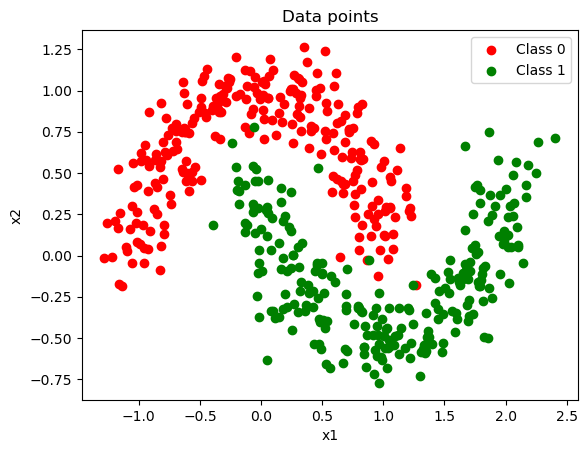

In [49]:
X, y = make_moons(n_samples=500,noise=0.15,random_state=1128)
#plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm")
plt.scatter(X[:,0][y==0],X[:,1][y==0],label="Class 0",c="red")
plt.scatter(X[:,0][y==1],X[:,1][y==1],label="Class 1",c="green")
plt.title("Data points")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

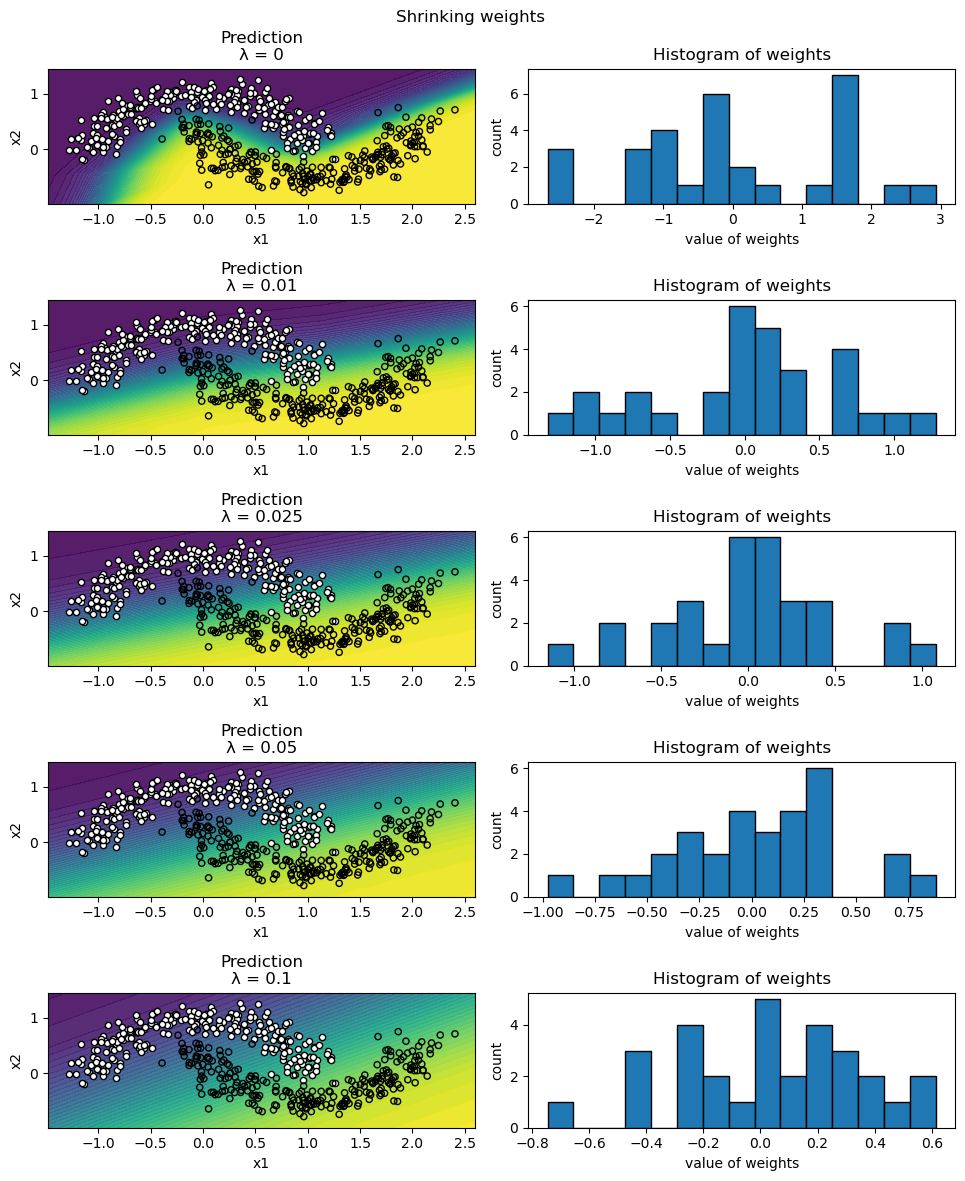

In [50]:
def plot_decision_boundary(ax, params, X, y):

    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),np.arange(y_min, y_max, 0.02))

    grid = np.c_[xx.ravel(), yy.ravel()]

    probs = forward(params, grid)["Y"]
    probs = probs.reshape(xx.shape)

    ax.contourf(xx,yy,probs,levels=50,cmap="viridis",alpha=0.9)
    ax.scatter(X[y == 0, 0],X[y == 0, 1],edgecolor="black",facecolor="white",s=20)
    ax.scatter(X[y == 1, 0],X[y == 1, 1],edgecolor="black",facecolor="none",s=20)

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")


lambdas = [0, 0.010, 0.025, 0.05, 0.1]
results = {}

for lbda in lambdas:

    params, losses = train(X,y.reshape(-1,1),hidden_sizes=[10],learning_rate=0.05,lbda=lbda,epochs=5000,verbose=False)
    results[lbda] = params

fig, axes = plt.subplots(len(lambdas),2,figsize=(10, 12))

for i, lbda in enumerate(lambdas):

    params = results[lbda]

    # Decision boundary
    ax = axes[i, 0]
    plot_decision_boundary(ax,params,X,y)
    ax.set_title(f"Prediction\nλ = {lbda}")

    # Histogram of weights
    weights = np.concatenate([params["W1"].ravel(),params["W2"].ravel()])

    ax = axes[i, 1]

    ax.hist(weights,bins=15,edgecolor="black")
    ax.set_title("Histogram of weights")
    ax.set_xlabel("value of weights")
    ax.set_ylabel("count")
    fig.suptitle("Shrinking weights")

plt.tight_layout()
plt.show()

<a class="anchor" id="ex1"></a>

### 2.4 Example 2: Structual Risk Minimization (SRM)

**Consider the same neural network as in <u>2.4 Example 1</u> but with varying hidden layer sizes.**


$$
y = \tau(W^{(2)}\sigma(W^{(1)}x + b^{(1)}) + b^{(2)})
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/93.jpg" width="550"/>
</div>


- $W^{(1)} \in \mathbb{R}^{1 \times 2}$
- $b^{(1)} \in \mathbb{R}^{1}$
- $X \in \mathbb{R}^{N \times 2}$
- $W^{(2)} \in \mathbb{R}^{1}$
- $b^{(2)} \in \mathbb{R}^{1}$
- $\sigma(x)=\text{ReLU}(x)=\max(0,x)$
- $\tau(x)=\text{sigmoid}(x)=\frac{1}{1+\exp(-x)}$

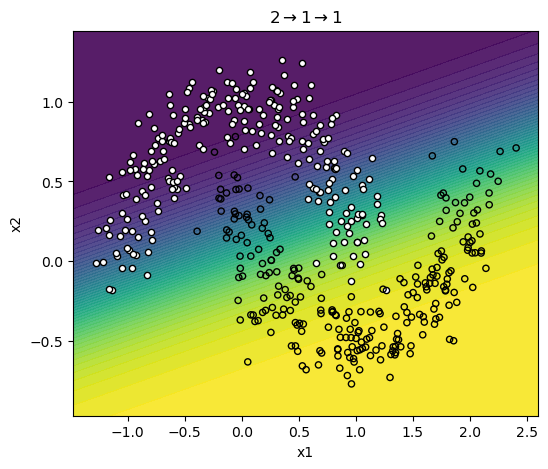

In [51]:
hidden_size = 1
params1, losses1 = train(X,y.reshape(-1,1),hidden_sizes=[hidden_size],learning_rate=0.05,lbda=0.0,epochs=5000,verbose=False)
fig, ax = plt.subplots(figsize=(6,5))
plot_decision_boundary(ax, params1, X, y)
ax.set_title(r"$2 \rightarrow 1 \rightarrow 1$")
plt.show()

$$
y = \tau(W^{(2)}\sigma(W^{(1)}x + b^{(1)}) + b^{(2)})
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/94.jpg" width="550"/>
</div>


- $W^{(1)} \in \mathbb{R}^{2 \times 2}$
- $b^{(1)} \in \mathbb{R}^{2}$
- $X \in \mathbb{R}^{N \times 2}$
- $W^{(2)} \in \mathbb{R}^{1 \times 2}$
- $b^{(2)} \in \mathbb{R}^{1}$
- $\sigma(x)=\text{ReLU}(x)=\max(0,x)$
- $\tau(x)=\text{sigmoid}(x)=\frac{1}{1+\exp(-x)}$

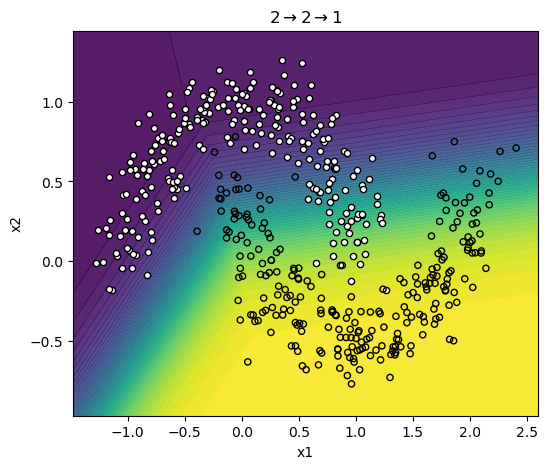

In [52]:
hidden_size = 2
params2, losses2 = train(X,y.reshape(-1,1),hidden_sizes=[hidden_size],learning_rate=0.05,lbda=0.0,epochs=5000,verbose=False)
fig, ax = plt.subplots(figsize=(6,5))
plot_decision_boundary(ax, params2, X, y)
ax.set_title(r"$2 \rightarrow 2 \rightarrow 1$")
plt.show()

$$
y = \tau(W^{(2)}\sigma(W^{(1)}x + b^{(1)}) + b^{(2)})
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/95.jpg" width="550"/>
</div>


- $W^{(1)} \in \mathbb{R}^{3 \times 2}$
- $b^{(1)} \in \mathbb{R}^{3}$
- $X \in \mathbb{R}^{N \times 2}$
- $W^{(2)} \in \mathbb{R}^{1 \times 3}$
- $b^{(2)} \in \mathbb{R}^{1}$
- $\sigma(x)=\text{ReLU}(x)=\max(0,x)$
- $\tau(x)=\text{sigmoid}(x)=\frac{1}{1+\exp(-x)}$

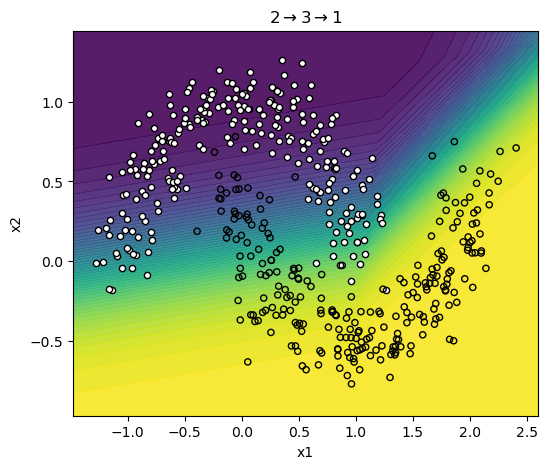

In [53]:
hidden_size = 3
params3, losses3 = train(X,y.reshape(-1,1),hidden_sizes=[hidden_size],learning_rate=0.05,lbda=0.0,epochs=5000,verbose=False)
fig, ax = plt.subplots(figsize=(6,5))
plot_decision_boundary(ax, params3, X, y)
ax.set_title(r"$2 \rightarrow 3 \rightarrow 1$")
plt.show()

$$
y = \tau(W^{(2)}\sigma(W^{(1)}x + b^{(1)}) + b^{(2)})
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/96.jpg" width="550"/>
</div>


- $W^{(1)} \in \mathbb{R}^{5 \times 2}$
- $b^{(1)} \in \mathbb{R}^{5}$
- $X \in \mathbb{R}^{N \times 2}$
- $W^{(2)} \in \mathbb{R}^{1 \times 5}$
- $b^{(2)} \in \mathbb{R}^{1}$
- $\sigma(x)=\text{ReLU}(x)=\max(0,x)$
- $\tau(x)=\text{sigmoid}(x)=\frac{1}{1+\exp(-x)}$

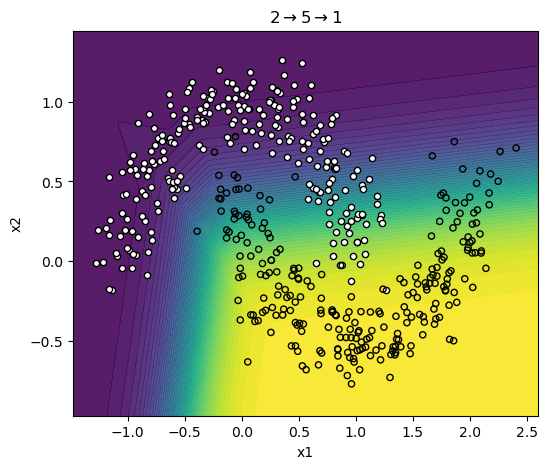

In [54]:
hidden_size = 5
params100, losses100 = train(X,y.reshape(-1,1),hidden_sizes=[hidden_size],learning_rate=0.05,lbda=0.0,epochs=5000,verbose=False)
fig, ax = plt.subplots(figsize=(6,5))
plot_decision_boundary(ax, params100, X, y)
ax.set_title(r"$2 \rightarrow 5 \rightarrow 1$")
plt.show()

$$
y = \tau(W^{(2)}\sigma(W^{(1)}x + b^{(1)}) + b^{(2)})
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/97.jpg" width="550"/>
</div>


- $W^{(1)} \in \mathbb{R}^{100 \times 2}$
- $b^{(1)} \in \mathbb{R}^{100}$
- $X \in \mathbb{R}^{N \times 2}$
- $W^{(2)} \in \mathbb{R}^{1 \times 100}$
- $b^{(2)} \in \mathbb{R}^{1}$
- $\sigma(x)=\text{ReLU}(x)=\max(0,x)$
- $\tau(x)=\text{sigmoid}(x)=\frac{1}{1+\exp(-x)}$

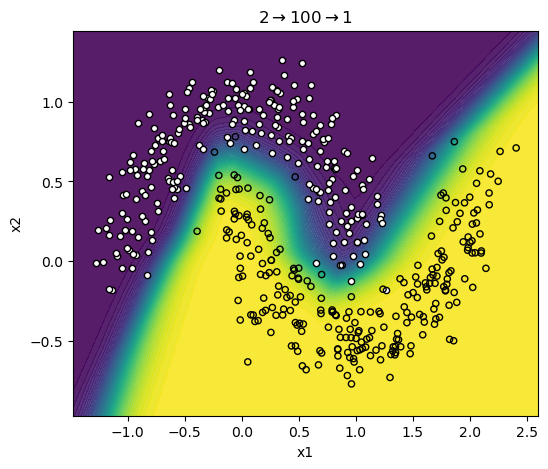

In [55]:
hidden_size = 100
params100, losses100 = train(X,y.reshape(-1,1),hidden_sizes=[hidden_size],learning_rate=0.05,lbda=0.0,epochs=5000,verbose=False)
fig, ax = plt.subplots(figsize=(6,5))
plot_decision_boundary(ax, params100, X, y)
ax.set_title(r"$2 \rightarrow 100 \rightarrow 1$")
plt.show()

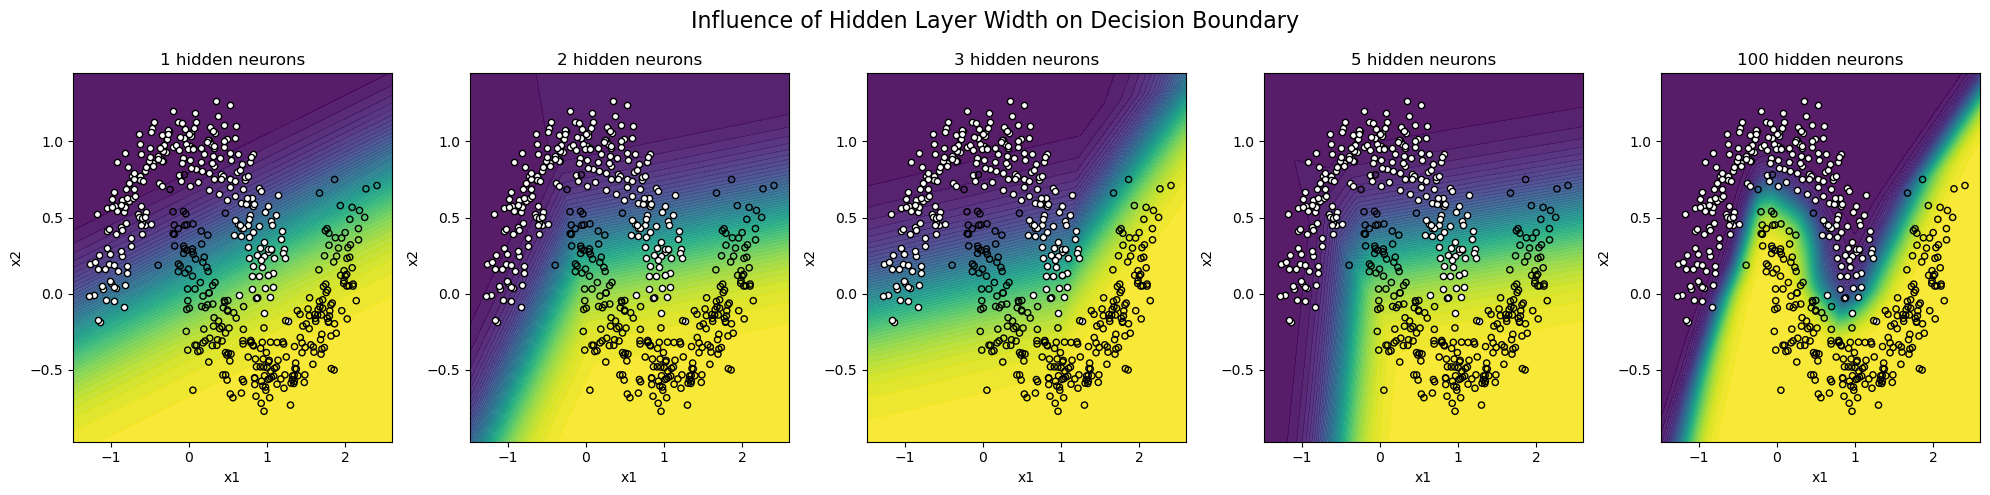

In [56]:
sizes = [1,2,3,5,100]
fig, axes = plt.subplots(1,len(sizes),figsize=(20,5))

for ax, size in zip(axes, sizes):
    params, _ = train(X,y.reshape(-1,1),hidden_sizes=[size],learning_rate=0.05,lbda=0.0,epochs=5000,verbose=False)
    plot_decision_boundary(ax, params, X, y)
    ax.set_title(f"{size} hidden neurons")

fig.suptitle("Influence of Hidden Layer Width on Decision Boundary",fontsize=16)
plt.tight_layout()
plt.show()

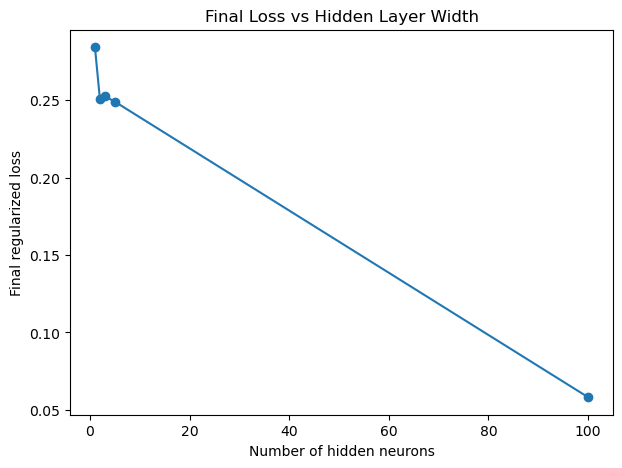

In [57]:
hidden_sizes = [1,2,3,5,100]
final_losses = []

for size in hidden_sizes:
    _, losses = train(X,y.reshape(-1,1),hidden_sizes=[size],learning_rate=0.05,lbda=0.0,epochs=5000,verbose=False)
    final_losses.append(losses[-1])

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(hidden_sizes,final_losses,marker="o")
ax.set_xlabel("Number of hidden neurons")
ax.set_ylabel("Final regularized loss")
ax.set_title("Final Loss vs Hidden Layer Width")
plt.show()

<a class="anchor" id="stop"></a>

# 3. Early Stopping

**Even without explicit regularization, training itself behaves like a regularizer.**

Initially:
- training loss decreases
- validation loss decreases

Eventually:
- training loss continues decreasing
- validation loss increases

At this point the model starts memorizing noise.

##### Procedure using iterative optimizers like Stochastic Gradient Descent:
1. Split data into tarin and validation set
2. Train on train set and evaluate the model on the validation set
3. Stop when validation error stops decreasing
4. Use parameters of the previous steos for the final model

Advantages
- simple
- computationally cheap
- very effective

It is one of the most widely used regularization methods next to Cross- Validation.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/98.png" width="550"/>
</div>

In [58]:
X, y = make_moons(n_samples=500,noise=0.15,random_state=1128)

y = y.reshape(-1,1)
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,random_state=1128,stratify=y)
print(X_train.shape)
print(X_val.shape)

def create_mini_batches(X, T, batch_size, rng):

    N = X.shape[0]

    indices = rng.permutation(N)

    X_shuffled = X[indices]
    T_shuffled = T[indices]

    for start in range(0, N, batch_size):

        end = min(start + batch_size, N)

        yield (X_shuffled[start:end],T_shuffled[start:end])

def train_sgd(X_train,T_train,X_val,T_val,hidden_sizes=[10],learning_rate=0.01,lbda=0.0,batch_size=32,epochs=500,patience=25,seed=2008,verbose=True):

    rng = np.random.default_rng(seed)
    params = initialize(seed=seed,input_dim=X_train.shape[1],output_dim=1,hidden_sizes=hidden_sizes)

    train_losses = []
    val_losses = []

    best_val_loss = np.inf
    best_params = None

    patience_counter = 0
    for epoch in range(epochs):


        # Mini-batch SGD
        for X_batch, T_batch in create_mini_batches(X_train,T_train,batch_size,rng):
            grads = backward(params,X_batch,T_batch,lbda)

            params = update(params,grads,learning_rate)


        # Evaluate after epoch
        Y_train = forward(params, X_train)["Y"]
        train_loss = RegularizedLoss(params,Y_train,T_train,lbda)

        Y_val = forward(params, X_val)["Y"]

        val_loss = RegularizedLoss(params,Y_val,T_val,lbda)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss

            best_params = {k: v.copy() for k, v in params.items()}
            patience_counter = 0

        else:
            patience_counter += 1

        if verbose and epoch % 10 == 0:

            print(f"Epoch {epoch:4d} | "f"Train Loss = {train_loss:.4f} | "f"Val Loss = {val_loss:.4f}")

        if patience_counter >= patience:

            print(f"Early stopping at epoch {epoch}")
            break

    return (best_params,train_losses,val_losses)

(400, 2)
(100, 2)


Epoch    0 | Train Loss = 0.3892 | Val Loss = 0.4031
Epoch   10 | Train Loss = 0.2532 | Val Loss = 0.3142
Epoch   20 | Train Loss = 0.2350 | Val Loss = 0.3193
Epoch   30 | Train Loss = 0.2245 | Val Loss = 0.3234
Early stopping at epoch 38


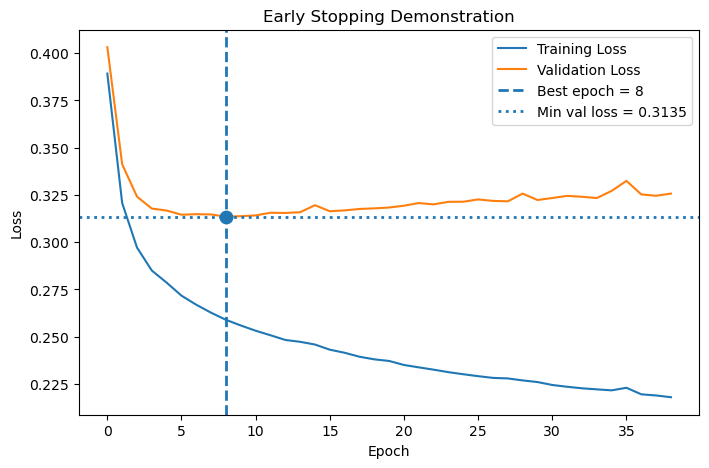

In [59]:
params, train_losses, val_losses = train_sgd(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_sizes=[100],
    learning_rate=0.05,
    lbda=0.0,
    batch_size=32,
    epochs=1000,
    patience=30,
    verbose=True)

best_epoch = np.argmin(val_losses)
best_val_loss = val_losses[best_epoch]

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(train_losses, label="Training Loss")
ax.plot(val_losses, label="Validation Loss")

# vertical line at best epoch
ax.axvline(best_epoch,linestyle="--",linewidth=2,label=f"Best epoch = {best_epoch}")

# horizontal line at minimum validation loss
ax.axhline(best_val_loss,linestyle=":",linewidth=2,label=f"Min val loss = {best_val_loss:.4f}")

# mark the point
ax.scatter(best_epoch,best_val_loss,s=80,zorder=5)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Early Stopping Demonstration")
ax.legend()

plt.show()

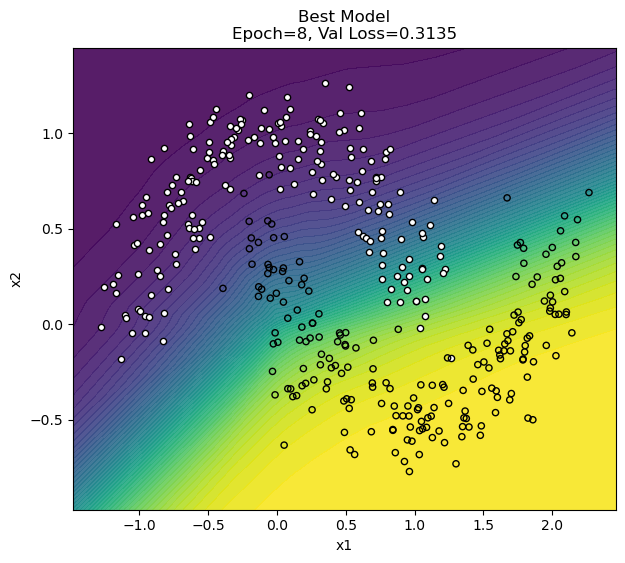

Train Accuracy : 0.8700
Validation Accuracy : 0.8300


In [60]:
fig, ax = plt.subplots(figsize=(7,6))

plot_decision_boundary(ax, params, X_train, y_train.ravel())
ax.set_title(f"Best Model\nEpoch={best_epoch}, Val Loss={best_val_loss:.4f}")
plt.show()

train_acc = accuracy(params, X_train, y_train)
val_acc   = accuracy(params, X_val, y_val)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")

<a class="anchor" id="drop"></a>

# 4. Dropout

**Goal: Reduce overfitting in neural networks by preventing complex
co-adaptations of neurons.**

- Dropout sets the activations of random subsets of neurons to zero during training which is called "dropping"
- The dropping of a given neuron is independent of the dropping of other neurons
- For a neural network with $N$ input or $N$ hidden neurons applying dropout to these can result in $2^N$ possible subnetworks


<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/99.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/100.png" width="550"/>
  <img src="pics/101.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/102.png" width="550"/>
</div>

### Dropout Algorithm
- Training with dropout requires a minibatch-based learning algorithm such as
stochastic gradient descent
- For each training case in a minibatch, randomly sample a binary vector $\mu$ with one entry for each input or hidden neuron in the network
- The entries of $\mu$ are sampled independently from each other
- The probability p of sampling a mask value of 0 (dropout) for one
neuron is a hyperparameter known as the "dropout rate"
- A typical value for the dropout rate is 0.2 for input neurons and 0.5 for
hidden neurons
- Each neuron in the network is multiplied by the corresponding mask
value resulting in a $\text{subnet}_\mu$
- Forward propagation, backpropagation, and the learning update
are run as usual

1. Define parent network and initialize weights
2. **for** each minibatch: **do**
3. $\quad$ **for** each training sample: **do**
4. $\quad \quad$ Draw binary vector $p$ using $p$
5. $\quad \quad$ Compute forward pass for $\text{subnet}_\mu$
6. $\quad$ **end for**
7. $\quad$ Update the weights of the (parent) network by performing a gradient descent step with weight decay
8. **end for**

- The derivatives with respect to each parameter are averaged over the training cases in each mini-batch
- Any training case which does not use a parameter contributes a gradient of zero for that parameter
- The weights of the network will be larger than normal because of
dropout
- To obtain a prediction at test time the weights
must be first scaled by the chosen dropout rate
- This means that if a unit (neuron) is retrained with probability $p$
during training, the weight at test time of that unit is multiplied by $p$
- Weight scaling ensures that the expected total input to a
neuron/unit at test time is roughly the same as the expected total
input to that unit at train time, even though many of the units at
train time were missing on average
- Inverse Dropout: Rescaling of the weights can also be performed at training time instead, after each weight update at the end of the mini-batch
- Keras and PyTorch deep learning libraries implement Inverse dropout


### Summary
During training, dropout randomly sets a subset of hidden-layer activations to zero by multiplying them with a binary mask. As a result, the dropped neurons do not contribute to the forward pass, their backpropagated errors become zero, and the corresponding incoming and outgoing weights receive no gradient update during that iteration. A new random mask is generated for each training iteration, so different subnetworks are trained, which reduces co-adaptation between neurons and improves generalization.

### Example of Dropout


$$
y = \tau(W^{(3)}\sigma(W^{(2)}\sigma(W^{(1)}x + b^{(1)}) + b^{(2)})+b^{(3)})
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/110.jpeg" width="550"/>
</div>


- $W^{(1)} \in \mathbb{R}^{10 \times 2}$
- $b^{(1)} \in \mathbb{R}^{10}$
- $X \in \mathbb{R}^{N \times 2}$
- $W^{(2)} \in \mathbb{R}^{10 \times 10}$
- $b^{(2)} \in \mathbb{R}^{10}$
- $W^{(3)} \in \mathbb{R}^{1 \times 10}$
- $b^{(3)} \in \mathbb{R}^{1}$
- $\sigma(x)=\text{ReLU}(x)=\max(0,x)$
- $\tau(x)=\text{sigmoid}(x)=\frac{1}{1+\exp(-x)}$
- $\lambda$ Regularization strength

##### Forward propagation
- $Z^{(0)}=X=\begin{bmatrix}x_1^\top \\ x_2^\top \\ \vdots \\ x_N^\top \end{bmatrix}$

- $A^{(1)}=\underbrace{Z^{(0)}(W^{(1)})^\top}_{(N\times2)(2\times10)=(N\times10)}+\underbrace{1_N(b^{(1)})^\top}_{N\times10}\in\mathbb{R}^{N\times10}$

- $Z^{(1)}=\sigma(A^{(1)})=\operatorname{ReLU}(A^{(1)})\in\mathbb{R}^{N\times10}$

- $A^{(2)}=\underbrace{Z^{(1)}(W^{(2)})^\top}_{(N\times10)(10\times10)=(N\times10)}+\underbrace{1_N(b^{(2)})^\top}_{N\times10}\in\mathbb{R}^{N\times10}$

- $Z^{(2)}=\sigma(A^{(2)})=\operatorname{ReLU}(A^{(2)})\in\mathbb{R}^{N\times10}$

- $A^{(3)}=\underbrace{Z^{(2)}(W^{(3)})^\top}_{(N\times10)(10\times1)=(N\times1)}+\underbrace{1_Nb^{(3)}}_{N\times1}\in\mathbb{R}^{N\times1}$

- $Z^{(3)}=\tau(A^{(3)})=\operatorname{sigmoid}(A^{(3)})\in\mathbb{R}^{N\times1}$

- $Y=Z^{(3)}$

- Binary Cross-Entropy loss
$$
\mathcal{R}_{\mathrm{emp}}(\ldots)
=L(Y,T)
=-\frac{1}{N}\sum_{i=1}^{N}
\left[
T_i\log(Y_i)
+
(1-T_i)\log(1-Y_i)
\right],
\qquad
T\in\mathbb{R}^{N\times1}.
$$


##### Backward propagation with L2 Regularization

Our Regularized Loss is
$$
\mathcal{R}_\text{reg}(\ldots)
=
\mathcal{R}_\text{emp}(\ldots)
+
\frac{\lambda}{2}
\left(
\lVert W^{(1)}\rVert_F^2
+
\lVert W^{(2)}\rVert_F^2
+
\lVert W^{(3)}\rVert_F^2
\right)
$$

and typically we do not regularize biases.

$$
\begin{align*}

\frac{\partial\mathcal{R}_\text{reg}}{\partial b^{(3)}}
&=
\frac{\partial\mathcal{R}_\text{reg}}{\partial\mathcal{R}_\text{reg}}
\frac{\partial\mathcal{R}_\text{reg}}{\partial\mathcal{R}_\text{emp}}
\frac{\partial\mathcal{R}_\text{emp}}{\partial Y}
\frac{\partial Y}{\partial A^{(3)}}
\frac{\partial A^{(3)}}{\partial b^{(3)}}
\\[2ex]

\frac{\partial\mathcal{R}_\text{reg}}{\partial W^{(3)}}
&=
\frac{\partial\mathcal{R}_\text{reg}}{\partial\mathcal{R}_\text{reg}}
\frac{\partial\mathcal{R}_\text{reg}}{\partial\mathcal{R}_\text{emp}}
\frac{\partial\mathcal{R}_\text{emp}}{\partial Y}
\frac{\partial Y}{\partial A^{(3)}}
\frac{\partial A^{(3)}}{\partial W^{(3)}}
+
\frac{\partial}{\partial W^{(3)}}
\frac{\lambda}{2}
\left(
\lVert W^{(1)}\rVert_F^2
+
\lVert W^{(2)}\rVert_F^2
+
\lVert W^{(3)}\rVert_F^2
\right)
\\[2ex]

\frac{\partial\mathcal{R}_\text{reg}}{\partial b^{(2)}}
&=
\frac{\partial\mathcal{R}_\text{reg}}{\partial\mathcal{R}_\text{reg}}
\frac{\partial\mathcal{R}_\text{reg}}{\partial\mathcal{R}_\text{emp}}
\frac{\partial\mathcal{R}_\text{emp}}{\partial Y}
\frac{\partial Y}{\partial A^{(3)}}
\frac{\partial A^{(3)}}{\partial Z^{(2)}}
\frac{\partial Z^{(2)}}{\partial A^{(2)}}
\frac{\partial A^{(2)}}{\partial b^{(2)}}
\\[2ex]

\frac{\partial\mathcal{R}_\text{reg}}{\partial W^{(2)}}
&=
\frac{\partial\mathcal{R}_\text{reg}}{\partial\mathcal{R}_\text{reg}}
\frac{\partial\mathcal{R}_\text{reg}}{\partial\mathcal{R}_\text{emp}}
\frac{\partial\mathcal{R}_\text{emp}}{\partial Y}
\frac{\partial Y}{\partial A^{(3)}}
\frac{\partial A^{(3)}}{\partial Z^{(2)}}
\frac{\partial Z^{(2)}}{\partial A^{(2)}}
\frac{\partial A^{(2)}}{\partial W^{(2)}}
+
\frac{\partial}{\partial W^{(2)}}
\frac{\lambda}{2}
\left(
\lVert W^{(1)}\rVert_F^2
+
\lVert W^{(2)}\rVert_F^2
+
\lVert W^{(3)}\rVert_F^2
\right)
\\[2ex]

\frac{\partial\mathcal{R}_\text{reg}}{\partial b^{(1)}}
&=
\frac{\partial\mathcal{R}_\text{reg}}{\partial\mathcal{R}_\text{reg}}
\frac{\partial\mathcal{R}_\text{reg}}{\partial\mathcal{R}_\text{emp}}
\frac{\partial\mathcal{R}_\text{emp}}{\partial Y}
\frac{\partial Y}{\partial A^{(3)}}
\frac{\partial A^{(3)}}{\partial Z^{(2)}}
\frac{\partial Z^{(2)}}{\partial A^{(2)}}
\frac{\partial A^{(2)}}{\partial Z^{(1)}}
\frac{\partial Z^{(1)}}{\partial A^{(1)}}
\frac{\partial A^{(1)}}{\partial b^{(1)}}
\\[2ex]

\frac{\partial\mathcal{R}_\text{reg}}{\partial W^{(1)}}
&=
\frac{\partial\mathcal{R}_\text{reg}}{\partial\mathcal{R}_\text{reg}}
\frac{\partial\mathcal{R}_\text{reg}}{\partial\mathcal{R}_\text{emp}}
\frac{\partial\mathcal{R}_\text{emp}}{\partial Y}
\frac{\partial Y}{\partial A^{(3)}}
\frac{\partial A^{(3)}}{\partial Z^{(2)}}
\frac{\partial Z^{(2)}}{\partial A^{(2)}}
\frac{\partial A^{(2)}}{\partial Z^{(1)}}
\frac{\partial Z^{(1)}}{\partial A^{(1)}}
\frac{\partial A^{(1)}}{\partial W^{(1)}}
+
\frac{\partial}{\partial W^{(1)}}
\frac{\lambda}{2}
\left(
\lVert W^{(1)}\rVert_F^2
+
\lVert W^{(2)}\rVert_F^2
+
\lVert W^{(3)}\rVert_F^2
\right).

\end{align*}
$$



---


$$
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}} = 1
$$


$$
\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}=\frac{1}{N}\left(-\frac{T}{Y} + \frac{1-T}{1-Y}\right)
$$

$$
\begin{align*}
\frac{\partial Y}{\partial A^{(3)}}
&=\frac{\partial}{\partial A^{(3)}} \tau(A^{(3)})\\
&=\frac{\partial}{\partial A^{(3)}} \frac{1}{1+\exp(-A^{(3)})} \\[1mm]
&=\frac{\partial}{\partial A^{(3)}} (1+\exp(-A^{(3)}))^{-1} \\[1mm]
&= -(1+\exp(-A^{(3)}))^{-2}
\frac{\partial}{\partial A^{(3)}}(1+\exp(-A^{(3)})) \\[1mm]
&= -(1+\exp(-A^{(3)}))^{-2}
(-\exp(-A^{(3)})) \\[1mm]
&=
\frac{\exp(-A^{(3)})}
{(1+\exp(-A^{(3)}))^2}
\hspace{1mm}\mid\hspace{1mm}
Y=\frac{1}{1+\exp(-A^{(3)})},
\;
1-Y=\frac{\exp(-A^{(3)})}{1+\exp(-A^{(3)})}
\\[1mm]
&=Y\odot(1-Y).
\end{align*}
$$

---

$$
\begin{align*}
\frac{\partial \mathcal{R}_\text{reg}}{\partial b^{(3)}}
&=
\underbrace{\left(
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}
\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}
\frac{\partial Y}{\partial A^{(3)}}
\right)}_{:=\delta^{(3)}=\frac{1}{N}(Y-T)}
\frac{\partial A^{(3)}}{\partial b^{(3)}}
\\
&=
1\cdot1\cdot
\frac{1}{N}
\left(
-\frac{T}{Y}
+
\frac{1-T}{1-Y}
\right)
\cdot
Y\odot(1-Y)
\cdot1
=
\frac{1}{N}1_N^\top(Y-T)
\\[3mm]

\frac{\partial \mathcal{R}_\text{reg}}{\partial W^{(3)}}
&=
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}
\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}
\frac{\partial Y}{\partial A^{(3)}}
\frac{\partial A^{(3)}}{\partial W^{(3)}}
+
\frac{\partial}{\partial W^{(3)}}
\frac{\lambda}{2}
\left(
\lVert W^{(1)}\rVert_F^2
+
\lVert W^{(2)}\rVert_F^2
+
\lVert W^{(3)}\rVert_F^2
\right)
\\
&=
(\delta^{(3)})^\top Z^{(2)}
+
\lambda W^{(3)}.
\end{align*}
\\
\begin{align*}

\frac{\partial \mathcal{R}_\text{reg}}{\partial b^{(2)}}
&=
\underbrace{\left(
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}
\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}
\frac{\partial Y}{\partial A^{(3)}}
\frac{\partial A^{(3)}}{\partial Z^{(2)}}
\frac{\partial Z^{(2)}}{\partial A^{(2)}}
\right)}_{:=\delta^{(2)}}
\frac{\partial A^{(2)}}{\partial b^{(2)}}
\\
&=
\underbrace{\left(
\delta^{(3)}W^{(3)}
\odot
\frac{\partial}{\partial A^{(2)}}\operatorname{ReLU}(A^{(2)})
\right)}_{\delta^{(2)}\text{ of shape }N\times10}
\odot1_N
\\
&=
1_N^\top\delta^{(2)}
\quad\mid\quad
\left[
\frac{\partial}{\partial A^{(2)}}\operatorname{ReLU}(A^{(2)})
\right]_{ij}
=
\begin{cases}
1,&A_{ij}^{(2)}>0,\\
0,&A_{ij}^{(2)}\le0.
\end{cases}
\\[3mm]

\frac{\partial \mathcal{R}_\text{reg}}{\partial W^{(2)}}
&=
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}
\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}
\frac{\partial Y}{\partial A^{(3)}}
\frac{\partial A^{(3)}}{\partial Z^{(2)}}
\frac{\partial Z^{(2)}}{\partial A^{(2)}}
\frac{\partial A^{(2)}}{\partial W^{(2)}}
+
\frac{\partial}{\partial W^{(2)}}
\frac{\lambda}{2}
\left(
\lVert W^{(1)}\rVert_F^2
+
\lVert W^{(2)}\rVert_F^2
+
\lVert W^{(3)}\rVert_F^2
\right)
\\
&=
(\delta^{(2)})^\top Z^{(1)}
+
\lambda W^{(2)}
\\[4mm]

\frac{\partial \mathcal{R}_\text{reg}}{\partial b^{(1)}}
&=
\underbrace{\left(
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}
\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}
\frac{\partial Y}{\partial A^{(3)}}
\frac{\partial A^{(3)}}{\partial Z^{(2)}}
\frac{\partial Z^{(2)}}{\partial A^{(2)}}
\frac{\partial A^{(2)}}{\partial Z^{(1)}}
\frac{\partial Z^{(1)}}{\partial A^{(1)}}
\right)}_{:=\delta^{(1)}}
\frac{\partial A^{(1)}}{\partial b^{(1)}}
\\
&=
\underbrace{\left(
\delta^{(2)}W^{(2)}
\odot
\frac{\partial}{\partial A^{(1)}}\operatorname{ReLU}(A^{(1)})
\right)}_{\delta^{(1)}\text{ of shape }N\times10}
\odot1_N
\\
&=
1_N^\top\delta^{(1)}
\quad\mid\quad
\left[
\frac{\partial}{\partial A^{(1)}}\operatorname{ReLU}(A^{(1)})
\right]_{ij}
=
\begin{cases}
1,&A_{ij}^{(1)}>0,\\
0,&A_{ij}^{(1)}\le0.
\end{cases}
\\[3mm]

\frac{\partial \mathcal{R}_\text{reg}}{\partial W^{(1)}}
&=
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}
\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}
\frac{\partial Y}{\partial A^{(3)}}
\frac{\partial A^{(3)}}{\partial Z^{(2)}}
\frac{\partial Z^{(2)}}{\partial A^{(2)}}
\frac{\partial A^{(2)}}{\partial Z^{(1)}}
\frac{\partial Z^{(1)}}{\partial A^{(1)}}
\frac{\partial A^{(1)}}{\partial W^{(1)}}
+
\frac{\partial}{\partial W^{(1)}}
\frac{\lambda}{2}
\left(
\lVert W^{(1)}\rVert_F^2
+
\lVert W^{(2)}\rVert_F^2
+
\lVert W^{(3)}\rVert_F^2
\right)
\\
&=
(\delta^{(1)})^\top X
+
\lambda W^{(1)}.

\end{align*}

$$



In [65]:
# activation functions
def relu(x):
    return np.maximum(0, x)

def relu_prime(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# Binary Cross-Entropy Loss
def Loss(Y, T):
    eps = 1e-12
    Y = np.clip(Y, eps, 1 - eps)  # avoid log(0)
    N = len(Y)
    return -np.sum(T * np.log(Y) + (1 - T) * np.log(1 - Y)) / N


# BCE + L2 Regularization
def RegularizedLoss(W1, W2, W3, Y, T, lbda):
    loss = Loss(Y, T)

    reg = np.sum(W1**2)+ np.sum(W2**2)+ np.sum(W3**2)

    return loss + 0.5 * lbda * reg


def forward(X,W1,b1,W2,b2,W3,b3,p_hidden=0.5,training=True):

    keep_prob = 1.0 - p_hidden

    # ---------- Hidden layer 1 ----------
    A1 = X @ W1.T + b1
    Z1 = relu(A1)

    if training:
        M1 = (np.random.rand(*Z1.shape) < keep_prob).astype(float)
        Z1 = (Z1 * M1) / keep_prob # Inverse dropout (divide by the keep probability during training) means no weight scaling is needed at test time
    else:
        M1 = np.ones_like(Z1)

    # ---------- Hidden layer 2 ----------
    A2 = Z1 @ W2.T + b2
    Z2 = relu(A2)

    if training:
        M2 = (np.random.rand(*Z2.shape) < keep_prob).astype(float)
        Z2 = (Z2 * M2) / keep_prob # Inverse dropout (divide by the keep probability during training) means no weight scaling is needed at test time
    else:
        M2 = np.ones_like(Z2)

    # ---------- Output ----------
    A3 = Z2 @ W3.T + b3
    Y = sigmoid(A3)

    cache = (A1,Z1,M1,A2,Z2,M2,A3,Y)
    return Y, cache


def backward(X,T,W1,W2,W3,cache,lam=0.0,p_hidden=0.5):

    keep_prob = 1.0 - p_hidden
    N = X.shape[0]

    A1,Z1,M1,A2,Z2,M2,A3,Y = cache


    # Output layer
    delta3 = (Y - T) / N

    dW3 = delta3.T @ Z2 + lam * W3
    db3 = np.sum(delta3, axis=0)


    # Hidden layer 2
    delta2 = delta3 @ W3

    delta2 *= relu_prime(A2)

    delta2 *= M2
    delta2 /= keep_prob

    dW2 = delta2.T @ Z1 + lam * W2
    db2 = np.sum(delta2, axis=0)


    # Hidden layer 1
    delta1 = delta2 @ W2

    delta1 *= relu_prime(A1)

    delta1 *= M1
    delta1 /= keep_prob

    dW1 = delta1.T @ X + lam * W1
    db1 = np.sum(delta1, axis=0)

    return dW1,db1,dW2,db2,dW3,db3

In [66]:
X, y = make_moons(n_samples=500,noise=0.15,random_state=1128)

y = y.reshape(-1,1)
X_train, X_test, T_train, T_test = train_test_split(X,y,test_size=0.2,random_state=1128,stratify=y)

hidden = 10

W1 = 0.1*np.random.randn(hidden,2)
b1 = np.zeros(hidden)

W2 = 0.1*np.random.randn(hidden,hidden)
b2 = np.zeros(hidden)

W3 = 0.1*np.random.randn(1,hidden)
b3 = np.zeros(1)

dropout_rate = 0.5
epochs=1000
eta = 0.1
lbda = 0.01

for epoch in range(epochs):

    Y, cache = forward(X_train,W1,b1,W2,b2,W3,b3,p_hidden=dropout_rate,training=True)

    dW1,db1,dW2,db2,dW3,db3 = backward(X_train,T_train,W1,W2,W3,cache,lam=lbda,p_hidden=dropout_rate)

    W1 -= eta*dW1
    b1 -= eta*db1

    W2 -= eta*dW2
    b2 -= eta*db2

    W3 -= eta*dW3
    b3 -= eta*db3

# No neurons are dropped during Test time
pred, _ = forward(X_test,W1,b1,W2,b2,W3,b3,training=False)
print(RegularizedLoss(W1, W2, W3, T_test, pred, lbda))

6.6970761970938915


<a class="anchor" id="augment"></a>

# 5. Data Augmentation

**Problem: Test error increases if the model complexity is high and the train set size is small.**

**Idea: Artificially increase the training data by increassing variation in inputs without changing the labels.**

### Example: Our original image is one of a cat

- Generate
    - rotated image
    - flipped
    - slighly brighter
    - cropped
    - shifted
- Now one image becomes many training examples

### Why?

The model learns

- cat rotated by 10 degrees
- cat rotated 20 degrees
- cat shifted

instead of memorizing individual pixels.

### Common augmentations
Images:
- rotation
- scaling
- pixel translation
- cropping
- flipping
- color jitter/color casting

Text:
- synonym replacement
- back translation

Audio:
- pitch shift
- speed change
- noise addition


### Benefit: Effectively increases dataset size without collecting new data.


<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/103.png" width="550"/>
  <img src="pics/104.png" width="550"/>
</div>

<a class="anchor" id="ensemble"></a>

# 6. Ensemble Methods

**Train several models separately, and aggregate their prediction.**

Regression $\Rightarrow$ Aggregate by averaging predictions of all $M$ model
$$
f(x)=\frac{1}{M}\sum_{i=1}^M f_i(x)
$$

Classification $\Rightarrow$ Aggregate by majority vote of all $M$ model predictions

**This improves performance on test set since different models will not make the same errors (less correlated errors).**

##### Construct ensembles
- construct by combining completely different kind of models (different learning algorithms and loss functions)
- construct by training the same model on k datasets constructed
by sampling n samples with replacement from original dataset (called bagging)

Since training a neural network repeatedly on the same dataset
results in different solutions it can even make sense to
combine those.


<a class="anchor" id="moment"></a>

# 7. SGD with Momentum

- Learning with Stochastic Gradient Descent (SGD) can be slow
- Momentum accelerates learning especially when we have small but consistent or noisy gradients
- Momentum aims to solve poor conditioning of the Hessian but also
variance in the stochastic gradient
- Ordinary SGD is $\theta^{[t+1]}=\theta^{[t]} - \alpha \nabla_\theta \mathcal{R}_\text{emp}(\theta^{[t]})$
- SGD with Momentum is 

$$
\nu_{t+1} = \varphi \nu_t - \alpha \underbrace{\nabla_\theta \left[\frac{1}{m} \sum_{i=1}^m L(y^{(i)},f(x^{(i)},\theta^{[t]}) \right] }_{\nabla_\theta \mathcal{R}_\text{emp}(\theta^{[t]})} \\[3 mm]

\theta^{[t+1]}=\theta^{[t]}+\nu_{t+1}
$$

- $\nu_{t+1}$ is an exponentially decaying moving
average of past gradients
- $\varphi \in [0,1)$ is a hyperparameter that determinines how
quickly the contribution of previous gradients decay
- Common values for $\varphi$ are 0.5,0.9 0r 0.99
- $\nu$ is called "velocity"

### SGD with Momentum Algorithm
1. **require** learning rate $\alpha$ and momentum $\varphi$
2. **require** initial parameter $\theta$ and initial velocity $\varphi$
3. **while** stopping criterion not met **do**
4. $\quad$ Samplea minibatch of $m$ examples from the training set $\{\tilde{x}^{(1)}, \ldots, \tilde{x}^{(m)}\}$
5. $\quad$ Compute gradient estimate: $\hat{g}=\frac{1}{m} \nabla_\theta \sum_{i=1}^m L(y^{(i)},f(\tilde{x}^{(i)},\theta))$
6. $\quad$ Compute velocity update: $\nu_{t+1} = \varphi \nu_t - \alpha \hat{g}$
7. $\quad$ Apply update: $\theta^{[t+1]} = \theta^{[t]} + \nu_{t+1}$
8. **end while**

##### Advantages of Momentum
- faster convergence
- smoother updates
- less oscillation
- easier optimization of deep networks

### SGD with Nesterov momentum
- Nesterov momentum modifies the momentum algorithm such that the gradient
is evaluated after the current velocity is applied

$$
\nu_{t+1} = \varphi \nu_t - \alpha \underbrace{\nabla_\theta \left[\frac{1}{m} \sum_{i=1}^m L(y^{(i)},f(x^{(i)},\theta^{[t]}+\varphi \nu) \right] }_{\nabla_\theta \mathcal{R}_\text{emp}(\theta^{[t]}+\varphi \nu)} \\[3 mm]

\theta^{[t+1]}=\theta^{[t]}+\nu_{t+1}
$$




- We can interpret Nesterov momentum as an attempt to add a correction factor to the basic method.
- The method is also called Nesterov accelerated gradient (NAG)

1. **require** learning rate $\alpha$ and momentum $\varphi$
2. **require** initial parameter $\theta$ and initial velocity $\nu$
3. **while** stopping criterion not met **do**
4. $\quad$ Sample minibatch of $m$ examples from the training set $\{\tilde{x}^{(1)}, \ldots, \tilde{x}^{(m)}\}$
5. $\quad$ Apply interim update: $\tilde{\theta} = \theta + \varphi \nu$
6. $\quad$ Compute gradient estimate: $\hat{g}=\frac{1}{m} \nabla_{\tilde{\theta}} \sum_{i=1}^m L(y^{(i)},f(\tilde{x}^{(i)},\tilde{\theta}))$
7. $\quad$ Compute velocity update: $\nu_{t+1} = \varphi \nu_t - \alpha \hat{g}$
8. $\quad$ Apply update: $\theta^{[t+1]} = \theta^{[t]} + \nu_{t+1}$
9. **end while**

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/105.png" width="600"/>
</div>


<a class="anchor" id="lr"></a>

# 8. Learning Rates

- The learning rate is a very important hyperparameter
- To systematically find a good learning rate, we can start at a very low learning rate and gradually increase it (linearly or exponentially) after each mini-batch
- We can then plot the learning rate and the training loss for each batch
- A good learning rate is one that results in a steep decline in the loss

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/106.png" width="600"/>
</div>

- When applying SGD, we decrease the learning rate over time, such that $\alpha^{[t]}$ is the learning rate at training iteration $t$
- The estimator $\hat{g}=\frac{1}{m} \nabla_{\tilde{\theta}} \sum_{i=1}^m L(y^{(i)},f(\tilde{x}^{(i)},\tilde{\theta}))$ is computed based on small batches
- A common strategy is to decay the learning rate linearly over time until iteration $\tau$: 
$$
\alpha^{[t]}=
\begin{cases} 
(1-\frac{t}{\tau})\alpha^{[0]} + \frac{t}{\tau}\alpha^{[\tau]} = t(-\frac{\alpha^{[0]}+\alpha^{[\tau]}}{\tau})+\alpha^{[0]} &\text{ for } t \leq \tau \\
\alpha^{[\tau]} & \text{ for } t > \tau
\end{cases}
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/107.png" width="600"/>
</div>


### Cyclical Learning rates
- Another option is to have a learning rate that periodically varies
according to some cyclic function
- Therefore, if training does not improve the loss anymore (possibly
due to saddle points), increasing the learning rate makes it
possible to rapidly traverse such regions
- Recall, saddle points are far more likely than local minima in deep
nets.
- Each cycle has a fixed length in terms of the number of iterations

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/108.png" width="600"/>
</div>

- Another option is to abruptly "restart" the learning rate after a
fixed number of iterations

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/109.png" width="600"/>
</div>

### Algorithms with Adaptive Learning Rates
- The learning rate is one of the hyperparameters that is the
most difficult to set because of its significant impact on the
models performance
- So it might make sense to use a different learning rate for each parameter, and automatically adapt them throughout the training process

##### Adagrad

- Adagrad adapts the learning rate to the parameters
- Adagrad scales learning rates inversely proportional to the
square root of the sum of the past squared derivatives
    - Parameters with large partial derivatives of the loss obtain a rapid decrease in their learning rate
    - Parameters with small partial derivatives on the other hand obtain a relatively small decrease in their learning rate
- For that reason, Adagrad might be well suited when dealing with sparse data

### Algorithm 3: Adagrad

1. **Require** global learning rate $\alpha$
2. **Require** initial parameter $\theta$
3. **Require** small constant $\beta$, e.g. $\beta \approx 10^{-7},$ for numerical stability
4. **Initialize** gradient accumulation variable $r = 0$
5. **while** the stopping criterion is not met **do**
   1. Sample a minibatch of $m$ examples from the training set $\left\{\tilde{x}^{(1)},\ldots,\tilde{x}^{(m)}\right\}$
   2. Compute the gradient estimate
      $\hat{g} \leftarrow \frac{1}{m} \nabla_{\theta} \sum_{i=1}^{m}
      L\!\left(y^{(i)},\,f\!\left(\tilde{x}^{(i)}\mid\theta\right)\right)$

   3. Accumulate the squared gradients
      $r\leftarrow r + \hat{g}\odot\hat{g},$ where $\odot$ denotes element-wise multiplication
   4. Compute the parameter update $\nabla\theta=-\frac{\alpha}{\beta+\sqrt{r}}\odot\hat{g},$ where the division and square root are applied element-wise
   5. Update the parameters $\theta \leftarrow\theta+\nabla\theta$
6. **End while**

- $\odot$ is the Hadamard or element-wise product
- $A=\begin{bmatrix}1 & 2\\3 & 4\end{bmatrix},\quad B=\begin{bmatrix}5 & 6\\7 & 8\end{bmatrix},\text{ then }
A\odot B=\begin{bmatrix}1\cdot5 & 2\cdot6\\3\cdot7 & 4\cdot8\end{bmatrix}$

##### RMSprop
- RMSprop is a modification of Adagrad
- It resolves Adagrad's radically diminishing learning rates
- The gradient accumulation is replaced by an exponentially weighted moving average
- Empirically, RMSProp is a very effective optimization algorithm
- RMSprop is employed routinely by deep learning practitioners

1. **Require** global learning rate $\alpha$ and decay rate $\rho \in [0,1)$
2. **Require** initial parameter $\theta$
3. **Require** small constant $\beta$, e.g. $\beta \approx 10^{-6},$ for numerical stability
4. **Initialize** gradient accumulation variable $r = 0$
5. **while** the stopping criterion is not met **do**
   1. Sample a minibatch of $m$ examples from the training set $\left\{\tilde{x}^{(1)},\ldots,\tilde{x}^{(m)}\right\}$
   2. Compute the gradient estimate
      $\hat{g} \leftarrow \frac{1}{m} \nabla_{\theta} \sum_{i=1}^{m}
      L\!\left(y^{(i)},\,f\!\left(\tilde{x}^{(i)}\mid\theta\right)\right)$

   3. **Accumulate the squared gradients
      $r \leftarrow \rho r + (1-\rho) \hat{g}\odot\hat{g},$ where $\odot$ denotes element-wise multiplication**
   4. Compute the parameter update $\nabla\theta=-\frac{\alpha}{\beta+\sqrt{r}}\odot\hat{g},$ where the division and square root are applied element-wise
   5. Update the parameters $\theta \leftarrow \theta +\nabla\theta$
6. **End while**


##### Adam
- Adaptive Moment Estimation (Adam) is another method that computes adaptive learning rates for each parameter
- Adam uses the first and the second moments of the gradients
    - Adam keeps an exponentially decaying average of past gradients (first moment)
    - Like RMSProp it stores an exponentially decaying average of past squared gradients (second moment)
- Basically Adam uses the combined averages of previous gradients at different moments 

1. **Require** step size $\alpha$ like 0.001
2. **Require** exponential decay rates for moment estimates $\rho_1 \in [0,1)$ and $\rho_2 \in [0,1)$ (suggested defaults: 0.9 and 0.999 respectively)
3. **Require** small constant $\beta$, e.g. $\beta \approx 10^{-8},$ for numerical stability
4. **Require** initial parameters $\theta$
5. **Initialize** time step $t$ = 0
6. **Initialize** 1st and 2nd moment variables $s^{[0]}=0=r^{[0]}$
7. **while** the stopping criterion is not met **do**
   1. $t \leftarrow t+1$
   2. Sample a minibatch of $m$ examples from the training set $\left\{\tilde{x}^{(1)},\ldots,\tilde{x}^{(m)}\right\}$
   3. Compute the gradient estimate
      $\hat{g}^{[t]} \leftarrow \frac{1}{m} \nabla_{\theta} \sum_{i=1}^{m}
      L\!\left(y^{(i)},\,f\!\left(\tilde{x}^{(i)}\mid\theta\right)\right)$

   4. Update biased first moment estimate: $s^{[t]} \leftarrow \rho_1 s^{[t-1]} + (1-\rho_1) \hat{g}^{[t]}$
   5. Update biased second moment estimate: $r^{[t]} \leftarrow \rho_2 r^{[t-1]} + (1-\rho_2) \hat{g}^{[t]} \odot \hat{g}^{[t]}$
   6. Correct bias in first moment: $\hat{s} \leftarrow \frac{s^{[t]}}{1-\rho_1^t}$
   7. Correct bias in second moment: $\hat{r} \leftarrow \frac{r^{[t]}}{1-\rho_2^t}$
   8. Compute the parameter update $\nabla\theta=-\frac{\hat{s}}{\beta+\sqrt{\hat{r}}}$
   9. Update the parameters $\theta \leftarrow\theta+\nabla\theta$
6. **End while**

<a class="anchor" id="batch"></a>

# 9. Batch Normalization (BatchNorm)

* BatchNorm  improves the training speed and stability of deep neural networks
* BatchNorm is an extra component that can be placed between each layer of
the neural network
* It changes the distribution of activations at each hidden layer of the network
* BatchNorm applies a similar transformation to the activations of
the hidden layers as the normalization of inputs to a learning algorithm by shifting and scaling all features to have mean 0 and unit variance
- For a hidden layer with neurons $z_j, j=1,\ldots,J$, BatchNorm is
applied to each $z_j$ by considering the activations of $z_j$ over a given
minibatch of inputs
- Let $z_j^{(j)}$ denote the activation of $z_j$ for input $x^{(i)}$ in the minibatch (of size $m$)
- The mean and variance of the activations are $$\mu_j = \frac{1}{m}\sum_{i=1}^m z_j^{(i)} \\[2 mm] \sigma_j^2 = \frac{1}{m}\sum_{i=1}^m (z_j^{(i)}-\mu_j)^2$$
- Each $z_j^{(i)}$ is now normalized $$\tilde{z}_j^{(i)}=\frac{z_j^{(i)}-\mu_j}{\sqrt{\sigma_j^2 + \varepsilon}} \quad \text{with } \varepsilon > 0 \text{ being a small constant for numerical stability}$$
- However normalizing activations in that way may result in loss of information 
- Therefor allow the traning algorithm to reshift and rescale $\tilde{z}_j^{(i)}$ to arrive at the batch normalized activation $\hat{z}_j^{(i)}$
$$
\hat{z}_j^{(i)} = \gamma \tilde{z}_j^{(i)} + \beta_i
$$
- $\gamma_j$ and $\beta_j$ are learnable parameters that are also tweaked by
backpropogation
- $\hat{z}_j^{(i)}$ then becomes the input to the next layer
- It is possible (and more common) to apply batch norm to the affine transformations $W_j^\top x + b_j$ before passing it to the nonlinear activation $\sigma$
- When the network is finished trained generate a
prediction for a single input (either at test time or in production) by feeding the entire training set to the (trained) network
and computing the means and standard deviations
- Or more commonly, during training, an exponentially weighted
running average of each of these statistics over the minibatches is
maintained
- The learned $\gamma$ and $\beta$ parameters are then used (in conjunction
with the running averages) to generate the output